# The Efficient Frontier

## Imports

In [329]:
import pandas as pd
import numpy as np
import random
from matplotlib import pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
from datetime import date
from dateutil.relativedelta import relativedelta
from scipy.optimize import minimize

from trading_algos import optimization as tao
from trading_algos import datasets as tad
from trading_algos import plots as tap
from trading_algos import utils as tau
from trading_algos.utils import head_tail as ht

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Load Data

In [330]:
# Choose a random selection of 5 stocks
random.seed(100)
n_assets = 5
tickers = tao.select_n(n_assets, tad.get_sp500_tickers())
df_stocks = tad.load_data(tickers=tickers, start_date='2020-01-01')
ht(df_stocks)

[*********************100%***********************]  5 of 5 completed


Price            Close                                                  \
Ticker             AEE         RJF         ROK         VLO         WAT   
Date                                                                     
2020-01-02   63.152264   55.048565  183.912857   73.667580  235.059998   
2020-01-03   63.177181   54.102573  181.229813   70.872025  231.009995   
2020-01-06   63.235291   53.884274  182.669708   70.879761  228.880005   
2026-06-10  108.769997  150.589996  440.070007  257.989990  363.179993   
2026-06-11  108.250000  150.419998  457.589996  255.600006  359.739990   
2026-06-12  109.000000  154.399994  459.339996  258.670013  355.529999   

Price             High                                                  ...  \
Ticker             AEE         RJF         ROK         VLO         WAT  ...   
Date                                                                    ...   
2020-01-02   64.024185   55.054630  183.912857   73.752763  236.289993  ...   
2020-01-03   63.567472   54.314812  181.757472   73.295864  233.830002  ...   
2020-01-06   63.434586   54.023743  182.732319   71.235979  230.449997  ...   
2026-06-10  109.449997  153.139999  461.829987  263.519989  377.500000  ...   
2026-06-11  110.250000  151.820007  459.890015  264.160004  364.709991  ...   
2026-06-12  109.660004  155.580002  463.880005  262.329987  365.000000  ...   

Price             Open                                                  \
Ticker             AEE         RJF         ROK         VLO         WAT   
Date                                                                     
2020-01-02   63.891323   54.593768  182.285158   73.280385  234.929993   
2020-01-03   62.977880   54.175342  180.576946   73.063545  231.539993   
2020-01-06   63.177162   53.581074  180.192372   70.554519  229.669998   
2026-06-10  109.120003  151.020004  461.820007  258.000000  370.029999   
2026-06-11  109.559998  150.399994  442.540009  264.040009  364.209991   
2026-06-12  108.699997  151.089996  462.329987  251.779999  359.820007   

Price        Volume                                     
Ticker          AEE      RJF      ROK      VLO     WAT  
Date                                                    
2020-01-02  1460900  1137600   638200  2130500  420100  
2020-01-03  1239900   830400   542600  5057000  389700  
2020-01-06  1381600   827850  1006900  3393200  406500  
2026-06-10  1309700  1241500   615500  2522900  515500  
2026-06-11  1424700  1038000   590400  3365200  836900  
2026-06-12  1331500  1181100   528700  2202700  780900  

[6 rows x 25 columns]

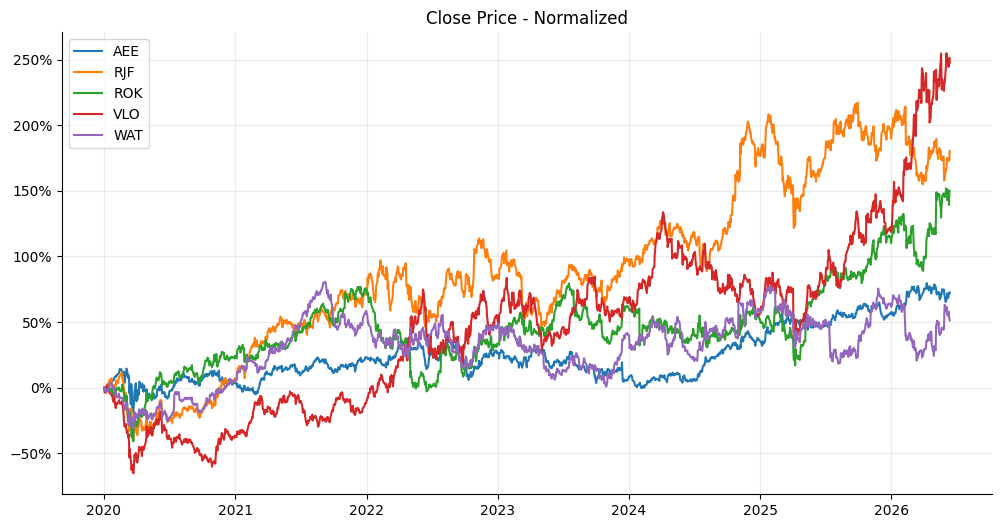

In [331]:
fig, ax = tap.trend(df_stocks, normalize=True)

## Compute Returns

In [332]:
log_prices = np.log(df_stocks.Close)
ht(log_prices)

Ticker,AEE,RJF,ROK,VLO,WAT
Date,,,,,
2020-01-02,4.145549,4.008216,5.214462,4.299563,5.459841
2020-01-03,4.145943,3.990882,5.199766,4.260876,5.442461
2020-01-06,4.146863,3.986839,5.207680,4.260985,5.433198
2026-06-10,4.689236,5.014561,6.086934,5.552921,5.894899
2026-06-11,4.684443,5.013431,6.125974,5.543614,5.885382
2026-06-12,4.691348,5.039547,6.129791,5.555553,5.873610


In [333]:
log_returns = (log_prices - log_prices.shift(1)).dropna()
ht(log_returns)

Ticker,AEE,RJF,ROK,VLO,WAT
Date,,,,,
2020-01-03,0.000394,-0.017334,-0.014696,-0.038687,-0.017380
2020-01-06,0.000919,-0.004043,0.007914,0.000109,-0.009263
2020-01-07,0.003670,0.010523,-0.002059,0.013025,0.013453
2026-06-10,0.007197,-0.005166,-0.045314,0.016453,-0.021708
2026-06-11,-0.004792,-0.001130,0.039040,-0.009307,-0.009517
2026-06-12,0.006905,0.026115,0.003817,0.011939,-0.011772


## Generating Many Random Portfolios

In [334]:
mu = log_returns.mean() * 252
mu

Ticker
AEE    0.084955
RJF    0.160528
ROK    0.142472
VLO    0.195497
WAT    0.064404
dtype: float64

In [335]:
cov = log_returns.cov() * 252
cov

Ticker,AEE,RJF,ROK,VLO,WAT
Ticker,,,,,
AEE,0.060470,0.031442,0.024727,0.027153,0.023839
RJF,0.031442,0.116074,0.064443,0.078811,0.045610
ROK,0.024727,0.064443,0.121284,0.059478,0.052456
VLO,0.027153,0.078811,0.059478,0.213477,0.042167
WAT,0.023839,0.045610,0.052456,0.042167,0.116163


In [336]:
def portfolio_return(weights):
    return np.dot(weights, mu)

def portfolio_volatility(weights):
    return np.sqrt(weights.T @ cov @ weights)

def sharpe_ratio(weights, rf=0.04):
    ret = portfolio_return(weights)
    vol = portfolio_volatility(weights)
    return (ret - rf) / vol

In [395]:
n_random = 100000

rand_returns = []
rand_vols = []
rand_sharpes = []
rand_weights = []

for _ in range(n_random):

    weights = np.random.random(n_assets)
    weights /= np.sum(weights)

    ret = portfolio_return(weights)
    vol = portfolio_volatility(weights)
    sharpe = sharpe_ratio(weights)

    rand_returns.append(ret)
    rand_vols.append(vol)
    rand_sharpes.append(sharpe)
    rand_weights.append(weights)

In [340]:
portfolios = pd.DataFrame({'Return': rand_returns,
                            'Risk': rand_vols,
                            'Sharpe': rand_sharpes,
                            'Weights': rand_weights})

## Portfolio Strategies

#### Equal Weighted Portfolio

In [342]:
equal_weights = np.ones(n_assets) / n_assets
equal_weights

array([0.2, 0.2, 0.2, 0.2, 0.2])

In [343]:
ewp_returns = log_returns.dot(equal_weights)

#### Max Sharpe Portfolio (Tangent Portfolio)

In [344]:
bounds = tuple((0, 1) for _ in range(n_assets))

weight_constraint = {
    'type': 'eq',
    'fun': lambda w: np.sum(w) - 1
}

# Our initial guess is a portfolio of equal weighting
initial_weights = np.ones(n_assets) / n_assets

In [346]:
rf = 0.04

max_sharpe = minimize(
    fun         = lambda w: -sharpe_ratio(w, rf),
    x0          = initial_weights,
    method      = 'SLSQP',
    bounds      = bounds,
    constraints = weight_constraint
)

w_max_sharpe = max_sharpe.x
w_max_sharpe

array([0.10104231, 0.37331223, 0.22869452, 0.29695094, 0.        ])

In [347]:
msp_returns = log_returns.dot(w_max_sharpe)

#### Minimum-Variance Portfolio

In [348]:
bounds = tuple((0, 1) for _ in range(n_assets))

weight_constraint = {
    'type': 'eq',
    'fun': lambda w: np.sum(w) - 1
}

# Our initial guess is a portfolio of equal weighting
initial_weights = np.ones(n_assets) / n_assets

# Minimize portfolio volatility
min_var = minimize(
    fun         = portfolio_volatility,
    x0          = initial_weights,
    method      = 'SLSQP',
    bounds      = bounds,
    constraints = weight_constraint
) 

w_min_var = min_var.x

In [349]:
w_min_var

array([0.58421379, 0.06821497, 0.12542209, 0.04637688, 0.17577227])

In [350]:
mvp_returns = log_returns.dot(w_min_var)

#### Plotting Portfolios

In [354]:
log_returns['EWP'] = ewp_returns
log_returns['MSP'] = msp_returns
log_returns['MVP'] = mvp_returns

In [355]:
log_returns

Ticker,AEE,RJF,ROK,VLO,WAT,EWP,MSP,MVP
Date,,,,,,,,
2020-01-03,0.000394,-0.017334,-0.014696,-0.038687,-0.017380,-0.017541,-0.021280,-0.007644
2020-01-06,0.000919,-0.004043,0.007914,0.000109,-0.009263,-0.000873,0.000426,-0.000369
2020-01-07,0.003670,0.010523,-0.002059,0.013025,0.013453,0.007723,0.007696,0.005573
2020-01-08,-0.001702,0.019300,0.007576,0.003875,-0.024569,0.000896,0.009916,-0.002867
2020-01-09,0.003794,0.014100,0.008678,0.022203,0.010766,0.011908,0.014225,0.007188
...,...,...,...,...,...,...,...,...
2026-06-08,-0.019592,-0.008354,0.011020,0.009996,-0.005544,-0.002495,0.000390,-0.011145
2026-06-09,0.014833,0.007826,0.019318,-0.018002,0.021267,0.009048,0.003492,0.014526
2026-06-10,0.007197,-0.005166,-0.045314,0.016453,-0.021708,-0.009708,-0.006679,-0.004884


In [357]:
log_returns.mean() * 252

Ticker
AEE    0.084955
RJF    0.160528
ROK    0.142472
VLO    0.195497
WAT    0.064404
EWP    0.129571
MSP    0.159147
MVP    0.098838
dtype: float64

In [358]:
log_returns.std() * np.sqrt(252)

Ticker
AEE    0.245907
RJF    0.340697
ROK    0.348258
VLO    0.462036
WAT    0.340827
EWP    0.247202
MSP    0.289242
MVP    0.214522
dtype: float64

In [359]:
(log_returns.mean() * 252) / (log_returns.std() * np.sqrt(252))

Ticker
AEE    0.345474
RJF    0.471177
ROK    0.409100
VLO    0.423121
WAT    0.188964
EWP    0.524151
MSP    0.550220
MVP    0.460738
dtype: float64

In [374]:
mu

Ticker
AEE    0.084955
RJF    0.160528
ROK    0.142472
VLO    0.195497
WAT    0.064404
dtype: float64

In [391]:
target_returns = np.linspace(
    mu.min(),
    mu.max(),
    1000
)

frontier_vols = []

for target in target_returns:

    constraints = [
        weight_constraint,
        {
            "type": "eq",
            "fun": lambda w, target=target:
                portfolio_return(w) - target
        }
    ]

    result = minimize(
        portfolio_volatility,
        initial_weights,
        method="SLSQP",
        bounds=bounds,
        constraints=constraints
    )

    if result.success:
        frontier_vols.append(result.fun)
    else:
        frontier_vols.append(np.nan)

In [392]:
len(target_returns)

1000

In [393]:
len(frontier_vols)

1000

In [411]:
target_returns / frontier_vols

array([0.18896357, 0.19031255, 0.1916715 , 0.19304043, 0.19441936,
       0.19580827, 0.19720718, 0.19861608, 0.20003496, 0.20146381,
       0.2029026 , 0.20435133, 0.20580995, 0.20727843, 0.20875674,
       0.21024482, 0.21174264, 0.21325012, 0.2147672 , 0.21629382,
       0.21782989, 0.21937533, 0.22093005, 0.22249393, 0.22406687,
       0.22564876, 0.22723946, 0.22883884, 0.23044675, 0.23206303,
       0.23368752, 0.23532005, 0.23696042, 0.23860845, 0.24026391,
       0.24192658, 0.24359625, 0.24527266, 0.24695555, 0.24864465,
       0.25033969, 0.25204037, 0.25374638, 0.25545738, 0.25717306,
       0.25889305, 0.260617  , 0.26234451, 0.2640752 , 0.26580865,
       0.26754443, 0.26928212, 0.27102125, 0.27276134, 0.27450192,
       0.27624247, 0.27798248, 0.27972141, 0.28145871, 0.28319382,
       0.28492616, 0.28665512, 0.2883801 , 0.29010046, 0.29181557,
       0.29352478, 0.2952274 , 0.29692276, 0.29861016, 0.30028889,
       0.30195824, 0.30361746, 0.30526582, 0.30690257, 0.30852

In [414]:
np.argmin(frontier_vols)

np.int64(262)

In [417]:
frontier_vols[250:270]

[np.float64(0.21457559104906648),
 np.float64(0.21456714247407332),
 np.float64(0.2145594153598184),
 np.float64(0.21455241013012472),
 np.float64(0.21454612685699037),
 np.float64(0.21454056560515755),
 np.float64(0.2145357264295033),
 np.float64(0.21453160937965018),
 np.float64(0.21452821450213008),
 np.float64(0.21452554182992375),
 np.float64(0.2145235913901003),
 np.float64(0.21452236320098425),
 np.float64(0.21452185728103657),
 np.float64(0.21452207363643652),
 np.float64(0.21452301226190992),
 np.float64(0.21452467315067042),
 np.float64(0.21452705628673432),
 np.float64(0.21453016165292607),
 np.float64(0.21453398921161648),
 np.float64(0.21453853892768712)]

(0.0, 0.4851378160981363)

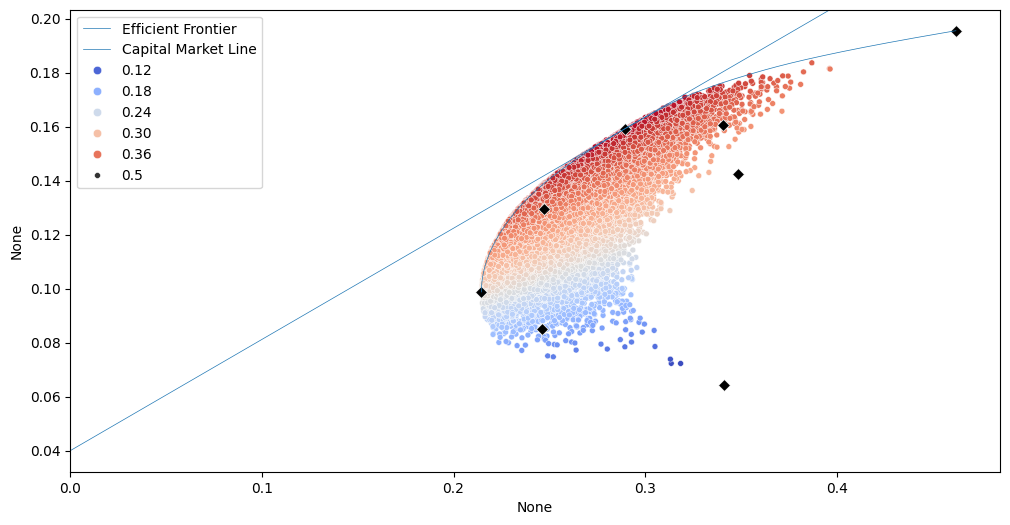

In [420]:
fig, ax = plt.subplots(figsize=(12,6))

ax.plot(
    frontier_vols[262:],
    target_returns[262:],
    linewidth=0.5,
    label="Efficient Frontier"
)
ax.axline((0,rf), (log_returns['MSP'].std() * np.sqrt(252), log_returns['MSP'].mean() * 252), linewidth=0.5, label='Capital Market Line')

sns.scatterplot(y=rand_returns, x=rand_vols, hue=rand_sharpes, size=0.5, ax=ax, palette='coolwarm')
sns.scatterplot(y=log_returns.mean() * 252, x=log_returns.std() * np.sqrt(252), marker='D', color='black')

ax.set_xlim(0, ax.get_xlim()[1])
